# Distance-to-Shoreline Rasters: from a marching idea to an exact, padding-free algorithm

**Goal:** for every pixel of an 8 m NOAA **BlueTopo** tile off the Florida coast, compute the distance (metres) to the
nearest shoreline from NOAA's official **Continually Updated Shoreline Product (CUSP)**. The output is a GeoTIFF on
exactly the same grid as the BlueTopo tile.

Along the way we compare several ways of sweeping the array, measure their speed and accuracy, and animate how they work.

| # | Method | Family | Idea |
|---|--------|--------|------|
| 0 | Brute force | raster | every pixel × every shoreline pixel |
| 1 | **1-D marching** (your idea) | raster | count up pixel by pixel, reset at shore, sweep back and keep the minimum |
| 2 | Chamfer two-pass | raster | your marching idea in 2-D with a neighbour mask (Rosenfeld & Pfaltz 1966, Borgefors 1986) |
| 3 | Exact separable EDT | raster | marching per column, then lower envelope of parabolas per row (Felzenszwalb & Huttenlocher 2012) |
| 4 | `scipy.ndimage.distance_transform_edt` | raster | Maurer et al. 2003, in C: the "tried and true" library call |
| 5 | KD-tree to shoreline vertices | vector | nearest-neighbour query for every pixel centre (our ground truth) |
| 6 | **Vector dead reckoning + halo + refinement** | hybrid | propagate *pointers to real shoreline points* in two passes; seed the tile border from off-tile shoreline; finish with a local exact search |

**Data sources (all official NOAA, public, no login):**
* BlueTopo: NOAA Office of Coast Survey, National Bathymetric Source. AWS Open Data bucket `noaa-ocs-nationalbathymetry-pds` ([registry](https://registry.opendata.aws/noaa-bathymetry), [specs](https://nauticalcharts.noaa.gov/data/bluetopo_specs.html)).
* Shoreline: NOAA National Geodetic Survey **CUSP** ([product page](https://shoreline.noaa.gov/data/datasheets/cusp.html), [NSDE downloads](https://nsde.ngs.noaa.gov/), [metadata](https://www.fisheries.noaa.gov/inport/item/60812)). CUSP ships as 5°×5° shapefile packages; we clip it to our area and save it as a **GeoPackage**.

The default tile, `BF2GS2KS`, covers Alligator Point / Ochlockonee Bay in the Florida Big Bend. It is an 8 m tile with a barrier spit, a bay,
marsh creeks and open Gulf: lots of "run into another shoreline" situations.

In [1]:
# If needed:  pip install numpy scipy rasterio geopandas shapely pyogrio pyproj numba matplotlib pillow requests pandas
import hashlib, json, math, time, re, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import shapely
import pyogrio
import pyproj
import rasterio
import requests
import numba as nb
from rasterio.features import rasterize
from rasterio.transform import Affine
from rasterio.warp import transform_bounds
from scipy import ndimage
from scipy.spatial import cKDTree

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image, display

warnings.filterwarnings("ignore", category=RuntimeWarning)

# ---------------- configuration ----------------
TILE_ID          = "BF2GS2KS"   # 8 m BlueTopo tile (Alligator Point / Ochlockonee Bay, FL)
SEARCH_BUFFER_M  = 30_000       # shoreline is gathered this far beyond the tile edge (must exceed the max distance in the tile)
DENSIFY_M        = 2.0          # shoreline vertices are densified to this spacing for the vector methods
MASK_TO_BLUETOPO = False        # True -> output is nodata wherever BlueTopo has no elevation
DATA_DIR = Path("data");     DATA_DIR.mkdir(exist_ok=True)
OUT_DIR  = Path("outputs");  OUT_DIR.mkdir(exist_ok=True)
BUCKET   = "https://noaa-ocs-nationalbathymetry-pds.s3.amazonaws.com"

# ---------------- plotting palette (single-hue sequential, neutral-midpoint diverging) ----------------
BLUE, ORANGE, INK, MUTED = "#2a78d6", "#eb6834", "#0b0b0b", "#8a8984"
DIST_CMAP = mcolors.LinearSegmentedColormap.from_list("dist", ["#e3eefb", "#a9cbf2", "#2a78d6", "#0b2d5c"])  # near shore = light
UNREACHED = "#c9c8c2"
ERR_CMAP  = plt.get_cmap("RdBu_r")
plt.rcParams.update({"figure.dpi": 90, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.edgecolor": MUTED, "axes.labelcolor": INK, "xtick.color": MUTED, "ytick.color": MUTED,
                     "axes.grid": False, "font.size": 10})

print("numba threads:", nb.config.NUMBA_NUM_THREADS)

numba threads: 10


## 1. Get the data

### 1a. BlueTopo tile
The BlueTopo **tile scheme** is a GeoPackage republished in the bucket with a date-stamped name, so we look up the current
one from the S3 listing. It gives each tile's resolution, UTM zone, download link and SHA-256 checksum.

In [2]:
def fetch(url, dest, sha256=None):
    # Download url -> dest once (cached). Verifies SHA-256 when given.
    dest = Path(dest); dest.parent.mkdir(parents=True, exist_ok=True)
    if not dest.exists():
        print(f"downloading {url}")
        tmp = dest.with_suffix(dest.suffix + ".part")
        with requests.get(url, stream=True, timeout=120) as r:
            r.raise_for_status()
            with open(tmp, "wb") as f:
                for chunk in r.iter_content(1 << 20):
                    f.write(chunk)
        tmp.rename(dest)
    if sha256:
        h = hashlib.sha256(dest.read_bytes()).hexdigest()
        assert h == sha256, f"checksum mismatch for {dest}"
    return dest

def latest_tile_scheme():
    xml = requests.get(f"{BUCKET}/?list-type=2&prefix=BlueTopo/_BlueTopo_Tile_Scheme/", timeout=60).text
    keys = sorted(re.findall(r"<Key>([^<]+\.gpkg)</Key>", xml))
    return fetch(f"{BUCKET}/{keys[-1]}", DATA_DIR / "bluetopo" / Path(keys[-1]).name)

scheme = gpd.read_file(latest_tile_scheme())
tile = scheme.loc[scheme.tile == TILE_ID].iloc[0]
print(scheme.Resolution.value_counts().to_dict())
print(tile.drop("geometry").to_string())
assert tile.Resolution == "8m", "pick an 8 m tile"

TIF = fetch(tile.GeoTIFF_Link, DATA_DIR / "bluetopo" / Path(tile.GeoTIFF_Link).name, tile.GeoTIFF_SHA256_Checksum)
fetch(tile.RAT_Link, DATA_DIR / "bluetopo" / Path(tile.RAT_Link).name)

{'4m': 7908, '8m': 519, '16m': 242, '2m': 20}
tile                                                                BF2GS2KS
GeoTIFF_Link               https://noaa-ocs-nationalbathymetry-pds.s3.ama...
RAT_Link                   https://noaa-ocs-nationalbathymetry-pds.s3.ama...
Delivered_Date                                           2026-08-27 12:15:46
Resolution                                                                8m
UTM                                                                       16
GeoTIFF_SHA256_Checksum    8b6c185fd96c87d7af011a1e5ebcf0cdc3114c59a636bd...
RAT_SHA256_Checksum        f4876e3f35ba7bf855f706c09f5e42add73093193be807...


PosixPath('data/bluetopo/BlueTopo_BF2GS2KS_20260820.tiff.aux.xml')

In [3]:
with rasterio.open(TIF) as ds:
    elev      = ds.read(1, masked=True)          # band 1 = Elevation (m, NAVD88); bands 2-3 = Uncertainty, Contributor
    TRANSFORM = ds.transform
    OUT_CRS   = ds.crs                            # compound UTM + NAVD88; kept as-is for the output
    H, W      = ds.shape
    BOUNDS    = ds.bounds
    PROFILE   = ds.profile

hcrs = pyproj.CRS.from_wkt(OUT_CRS.to_wkt())
HCRS = hcrs.sub_crs_list[0] if hcrs.is_compound else hcrs   # horizontal CRS for vector work
RES  = TRANSFORM.a
assert abs(TRANSFORM.a) == abs(TRANSFORM.e) and TRANSFORM.b == TRANSFORM.d == 0, "square, north-up pixels expected"

# pixel-centre coordinates
PX_X = TRANSFORM.c + (np.arange(W) + 0.5) * RES
PX_Y = TRANSFORM.f - (np.arange(H) + 0.5) * RES
print(f"{TIF.name}: {H} rows x {W} cols = {H*W/1e6:.1f} Mpx @ {RES:g} m, {HCRS.name}")
print(f"BlueTopo coverage: {100*(1-elev.mask.mean()):.1f}% of pixels")

BlueTopo_BF2GS2KS_20260820.tiff: 4246 rows x 3724 cols = 15.8 Mpx @ 8 m, NAD83 / UTM zone 16N
BlueTopo coverage: 75.3% of pixels


### 1b. CUSP shoreline → GeoPackage
CUSP is distributed by NGS as 5°×5° zip packages named by their south-west corner (for example `N25W085`). We download every
package touching the tile plus a **search buffer** (`SEARCH_BUFFER_M`), read only the features inside that box, reproject to the
tile's UTM zone, and save the result as a GeoPackage.

The buffer matters: a pixel near the tile edge may be closest to a shoreline that lies *outside* the tile.

In [4]:
BUF_BOX = (BOUNDS.left - SEARCH_BUFFER_M, BOUNDS.bottom - SEARCH_BUFFER_M,
           BOUNDS.right + SEARCH_BUFFER_M, BOUNDS.top + SEARCH_BUFFER_M)
w, s, e, n = transform_bounds(HCRS, "EPSG:4269", *BUF_BOX)

def cusp_regions(w, s, e, n):
    names = []
    for lat in range(int(math.floor(s / 5) * 5), int(math.ceil(n / 5) * 5), 5):
        for lon_w in range(int(math.ceil(-e / 5) * 5), int(math.ceil(-w / 5) * 5) + 5, 5):
            names.append(f"N{lat:02d}W{lon_w:03d}")
    return names

parts = []
for name in cusp_regions(w, s, e, n):
    z = DATA_DIR / "cusp" / f"{name}.zip"
    try:
        fetch(f"https://nsde.ngs.noaa.gov/downloads/{name}.zip", z)
    except requests.HTTPError:
        print(f"  no CUSP package {name} (open ocean)"); continue
    parts.append(pyogrio.read_dataframe(f"/vsizip/{z}/{name}.shp", bbox=(w, s, e, n)))

shore = gpd.GeoDataFrame(pd.concat(parts, ignore_index=True), crs=parts[0].crs).to_crs(HCRS)
shore = shore.clip(shapely.box(*BUF_BOX)).explode(index_parts=False)
shore = shore[shore.geom_type == "LineString"].reset_index(drop=True)

SHORE_GPKG = DATA_DIR / "shoreline" / f"CUSP_{TILE_ID}_buffer{SEARCH_BUFFER_M//1000}km.gpkg"
SHORE_GPKG.parent.mkdir(exist_ok=True)
shore.to_file(SHORE_GPKG, layer="cusp_shoreline", driver="GPKG")
print(f"{len(shore):,} shoreline lines, {shore.length.sum()/1000:,.0f} km -> {SHORE_GPKG}")
shore.ATTRIBUTE.value_counts().head(8)

15,054 shoreline lines, 4,933 km -> data/shoreline/CUSP_BF2GS2KS_buffer30km.gpkg


ATTRIBUTE
Natural.Apparent.Marsh Or Swamp         11954
Natural.Mean High Water                  1356
Natural.Apparent.Mangrove Or Cypress      905
Man-made.Bulkhead Or Sea Wall             427
Man-made.Rip Rap                          261
Man-made.Ramp                              80
Natural.Mean High Water.Approximate        20
Breakwater.Bare                            18
Name: count, dtype: int64

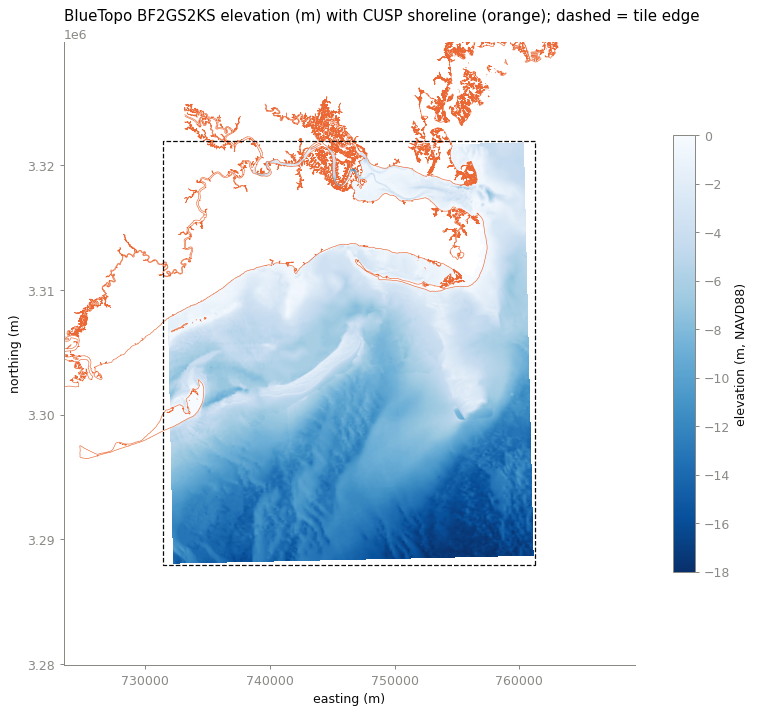

In [5]:
fig, ax = plt.subplots(figsize=(11, 9))
ext = (BOUNDS.left, BOUNDS.right, BOUNDS.bottom, BOUNDS.top)
im = ax.imshow(elev, extent=ext, cmap="Blues_r", vmin=-18, vmax=0)
shore.plot(ax=ax, color=ORANGE, lw=0.5)
ax.plot(*shapely.box(*BOUNDS).exterior.xy, color=INK, lw=1, ls="--")
pad = 8000
ax.set_xlim(BOUNDS.left - pad, BOUNDS.right + pad); ax.set_ylim(BOUNDS.bottom - pad, BOUNDS.top + pad)
ax.set_title(f"BlueTopo {TILE_ID} elevation (m) with CUSP shoreline (orange); dashed = tile edge", loc="left")
fig.colorbar(im, ax=ax, shrink=0.7, label="elevation (m, NAVD88)")
ax.set_xlabel("easting (m)"); ax.set_ylabel("northing (m)")
plt.show()

## 2. Framing the problem

There are two ways to define "the shoreline" on a raster:

* **Raster seeds:** burn the shoreline lines into the grid (`all_touched=True`) and measure pixel-centre to pixel-centre.
  Every distance-transform algorithm works on this. Because a seed pixel's centre can be up to half a pixel diagonal
  (`8·√2/2 ≈ 5.66 m`) from the actual line, the answer can be off by about ±5.7 m, even with an exact algorithm.
* **Vector truth:** distance from each pixel centre to the shoreline geometry itself. This is what "distance from the
  shoreline in metres" really means. We use it as the reference for scoring.

We also need to handle the **tile edge**: raster methods only see seeds inside the array, so they need padding out to the
search buffer. That is 3,750 px per side here, which makes the array **8× larger**.

In [6]:
def burn(transform, shape):
    return rasterize(((g, 1) for g in shore.geometry), out_shape=shape, transform=transform,
                     all_touched=True, dtype="uint8").astype(bool)

seeds = burn(TRANSFORM, (H, W))                                   # tile grid only
PAD = int(math.ceil(SEARCH_BUFFER_M / RES))
seeds_pad = burn(TRANSFORM * Affine.translation(-PAD, -PAD), (H + 2 * PAD, W + 2 * PAD))
unpad = (slice(PAD, PAD + H), slice(PAD, PAD + W))
print(f"seed pixels in tile: {seeds.sum():,}   padded grid: {seeds_pad.shape[0]}x{seeds_pad.shape[1]} "
      f"= {seeds_pad.size/1e6:.0f} Mpx ({seeds_pad.size/seeds.size:.1f}x the tile)")

results = []   # benchmark registry
def record(name, family, impl, n_px, seconds, dist=None, note=""):
    row = dict(method=name, family=family, implementation=impl, pixels_processed=n_px, seconds=seconds,
               Mpx_per_s=n_px / seconds / 1e6, note=note)
    if dist is not None:
        err = dist - D_REF
        row.update(mean_abs_err_m=float(np.abs(err).mean()), max_abs_err_m=float(np.abs(err).max()),
                   pct_within_1m=float(100 * (np.abs(err) <= 1).mean()))
    results.append(row)
    return row

def best_time(fn, repeat=3):
    best, out = float("inf"), None
    for _ in range(repeat):
        t = time.perf_counter(); out = fn(); best = min(best, time.perf_counter() - t)
    return best, out

seed pixels in tile: 119,394   padded grid: 11746x11224 = 132 Mpx (8.3x the tile)


## 3. Ground truth: KD-tree nearest-vertex query (Method 5)

Densify every shoreline line to ≤ 2 m vertex spacing, build a KD-tree, and ask it for the nearest vertex to all
15.8 M pixel centres. This is exact apart from densification: with vertex spacing *s* = 2 m the error is at most about $(s/2)^2/2d$, which is
well under a metre right at the shore and about 1 mm at 500 m. It is simple and correct, but slow, because every far-offshore
pixel has thousands of almost-equidistant candidates to check.

In [7]:
dense = shapely.segmentize(shore.geometry.values, DENSIFY_M)
PTS = shapely.get_coordinates(dense)
t0 = time.perf_counter()
TREE = cKDTree(PTS)
t_build = time.perf_counter() - t0

def kdtree_all_pixels():
    out = np.empty((H, W))
    for r0 in range(0, H, 512):                           # row blocks keep memory modest
        X, Y = np.meshgrid(PX_X, PX_Y[r0:r0 + 512])
        out[r0:r0 + 512] = TREE.query(np.column_stack([X.ravel(), Y.ravel()]), workers=-1)[0].reshape(X.shape)
    return out

t_query, D_REF = best_time(kdtree_all_pixels, repeat=1)
assert D_REF.max() < SEARCH_BUFFER_M, "increase SEARCH_BUFFER_M: some pixel's nearest shore may be outside the buffer"
print(f"{len(PTS):,} vertices | build {t_build:.1f}s | query {t_query:.1f}s | max distance in tile {D_REF.max()/1000:.2f} km")

# sanity check the reference against shapely's exact point-to-line distance on random pixels
rng = np.random.default_rng(0)
ri, ci = rng.integers(0, H, 3000), rng.integers(0, W, 3000)
union = shapely.union_all(shore.geometry.values)
exact = shapely.distance(shapely.points(PX_X[ci], PX_Y[ri]), union)
print(f"reference vs exact line distance on 3000 random pixels: max diff {np.abs(D_REF[ri, ci] - exact).max():.4f} m")
record("KD-tree to shoreline vertices", "vector", "scipy cKDTree (C++, all cores)", H * W, t_build + t_query, D_REF,
       "ground truth")

3,242,774 vertices | build 0.4s | query 30.5s | max distance in tile 22.99 km
reference vs exact line distance on 3000 random pixels: max diff 0.3998 m


{'method': 'KD-tree to shoreline vertices',
 'family': 'vector',
 'implementation': 'scipy cKDTree (C++, all cores)',
 'pixels_processed': 15812104,
 'seconds': 30.888600292,
 'Mpx_per_s': 0.5119074302662805,
 'note': 'ground truth',
 'mean_abs_err_m': 0.0,
 'max_abs_err_m': 0.0,
 'pct_within_1m': 100.0}

## 4. Method 0: brute force

For each pixel, loop over every shoreline (seed) pixel and keep the smallest distance. It is $O(N_{pixels}\times N_{seeds})$.
We time a random sample with vectorised NumPy and extrapolate.

In [8]:
seed_rc = np.argwhere(seeds_pad).astype(np.float64)               # all seeds in the padded search area
sample = rng.integers(0, H * W, 200)
def brute():
    out = []
    for k in sample:
        r, c = divmod(k, W)
        out.append(np.sqrt(((seed_rc - (r + PAD, c + PAD)) ** 2).sum(1)).min() * RES)
    return np.array(out)
t, d_brute = best_time(brute, repeat=1)
t_full = t / len(sample) * H * W
print(f"{len(seed_rc):,} seeds | {t/len(sample)*1e3:.1f} ms per pixel -> {t_full/3600:.1f} hours for the tile (extrapolated)")
print("matches exact raster EDT on the sample:",
      np.allclose(d_brute, (ndimage.distance_transform_edt(~seeds_pad)[unpad] * RES).ravel()[sample]))
results.append(dict(method="Brute force (NumPy)", family="raster", implementation="NumPy, extrapolated",
                    pixels_processed=H * W, seconds=t_full, Mpx_per_s=H * W / t_full / 1e6, note="extrapolated from 200 px"))

593,528 seeds | 0.8 ms per pixel -> 3.3 hours for the tile (extrapolated)
matches exact raster EDT on the sample: True


## 5. Method 1: your idea, 1-D marching

> *"Increment distance pixel by pixel as it loops through the data set, and go backwards if it runs into another shoreline."*

In one dimension this is exactly right and optimal ($O(n)$):

1. **Forward sweep:** `d[i] = 0` on a shoreline pixel, otherwise `d[i] = d[i-1] + 1`.
2. **Backward sweep:** `d[i] = min(d[i], d[i+1] + 1)`. This catches pixels that are closer to the *next* shoreline.

The animation runs it on a real transect across the marsh, where it crosses several shorelines.

In [9]:
def march_1d(is_shore):
    # Pure Python, exactly as described: count up, reset at shore, then sweep back keeping the min.
    n = len(is_shore); INF = float("inf"); d = [INF] * n
    for i in range(n):                                            # forward
        d[i] = 0.0 if is_shore[i] else (d[i - 1] + 1 if i else INF)
    for i in range(n - 2, -1, -1):                                # backward
        d[i] = min(d[i], d[i + 1] + 1)
    return d

TR_ROW, TR_C0, TR_C1 = 320, 800, 1300                            # 4 km transect crossing six shorelines
transect = seeds[TR_ROW, TR_C0:TR_C1]
d1 = np.array(march_1d(list(transect))) * RES
print(f"transect: {transect.size} px, {transect.sum()} shoreline crossings (pixels)")

transect: 500 px, 19 shoreline crossings (pixels)


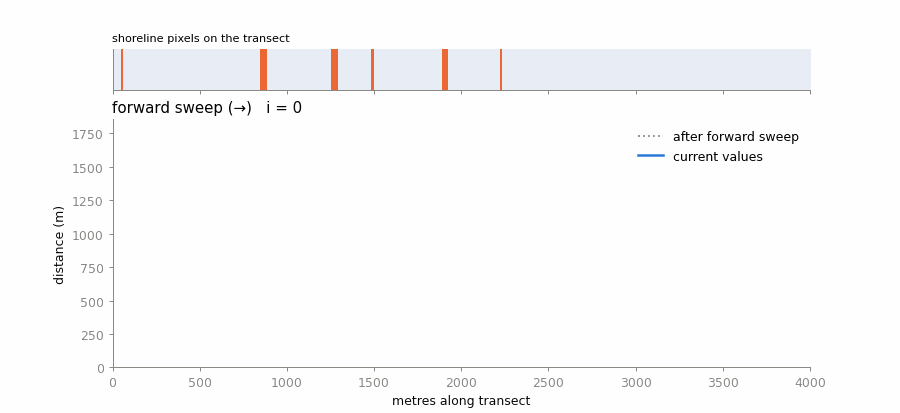

In [10]:
def animate_1d(is_shore, path, step=6):
    n = len(is_shore); INF = np.inf
    fwd = np.full(n, INF); frames = []
    for i in range(n):
        fwd[i] = 0 if is_shore[i] else (fwd[i - 1] + 1 if i else INF)
        if i % step == 0 or i == n - 1: frames.append(("forward", i, fwd.copy()))
    bwd = fwd.copy()
    for i in range(n - 2, -1, -1):
        bwd[i] = min(bwd[i], bwd[i + 1] + 1)
        if i % step == 0 or i == 0: frames.append(("backward", i, bwd.copy()))
    frames += [frames[-1]] * 15

    fig, (ax0, ax) = plt.subplots(2, 1, figsize=(10, 4.6), height_ratios=[1, 6], sharex=True)
    ax0.imshow(is_shore[None, :], aspect="auto", cmap=mcolors.ListedColormap(["#e8eef6", ORANGE]),
               extent=(0, n * RES, 0, 1)); ax0.set_yticks([]); ax0.set_title("shoreline pixels on the transect", loc="left", fontsize=9)
    x = np.arange(n) * RES
    ymax = np.nanmax(np.where(np.isinf(fwd), np.nan, fwd)) * RES * 1.05
    ghost, = ax.plot([], [], color=MUTED, lw=1.5, ls=":", label="after forward sweep")
    line,  = ax.plot([], [], color=BLUE, lw=2, label="current values")
    cursor = ax.axvline(0, color=ORANGE, lw=1.5)
    title = ax.set_title("", loc="left")
    ax.set_ylim(0, ymax); ax.set_xlim(0, n * RES); ax.set_xlabel("metres along transect"); ax.set_ylabel("distance (m)")
    ax.legend(loc="upper right", frameon=False)
    def update(k):
        phase, i, vals = frames[k]
        line.set_data(x, np.where(np.isinf(vals), np.nan, vals * RES))
        ghost.set_data(x, np.where(np.isinf(fwd), np.nan, fwd * RES) if phase == "backward" else [np.nan] * n)
        cursor.set_xdata([i * RES]); title.set_text(f"{phase} sweep ({'→' if phase == 'forward' else '←'})   i = {i}")
        return line, ghost, cursor, title
    FuncAnimation(fig, update, frames=len(frames), blit=False).save(path, writer=PillowWriter(fps=24))
    plt.close(fig)
    return path

display(Image(filename=animate_1d(transect, OUT_DIR / "anim_1d_marching.gif")))

**Extending it to 2-D.** Running the 1-D march along every row only measures the **horizontal** distance to shore. Adding a
column march and taking `min(row, col)` still only looks along the four axis directions, so pixels whose nearest shore is
diagonal come out too far. The error map below shows this. Both 2-D fixes reuse your two-sweep idea:

* **Chamfer** (Method 2): during each sweep, look at diagonal neighbours as well as the previous pixel.
* **Separable exact EDT** (Method 3): keep your 1-D march for the columns, then combine rows with a *lower envelope of parabolas*.

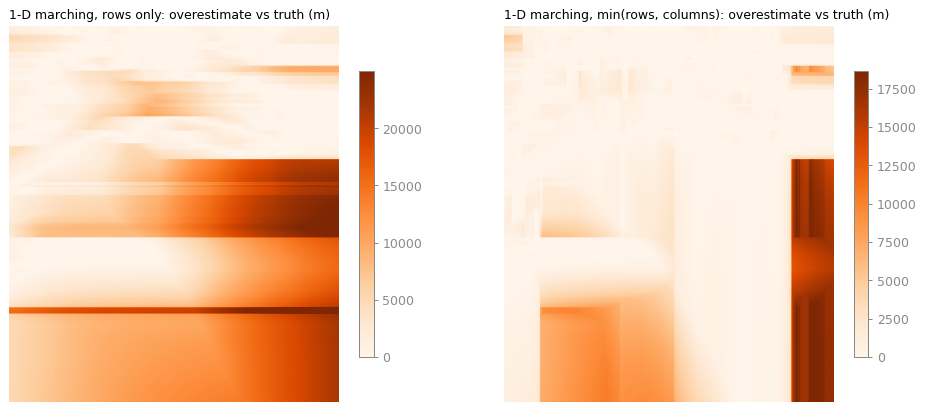

In [11]:
@nb.njit(parallel=True, cache=True)
def march_rows(seeds):
    # Your 1-D forward/backward march applied independently to every row (parallel over rows).
    H, W = seeds.shape
    d = np.empty((H, W))
    for i in nb.prange(H):
        prev = 1e20
        for j in range(W):
            prev = 0.0 if seeds[i, j] else prev + 1.0
            d[i, j] = prev
        for j in range(W - 2, -1, -1):
            if d[i, j + 1] + 1.0 < d[i, j]:
                d[i, j] = d[i, j + 1] + 1.0
    return d

march_rows(seeds[:8, :8])                                         # JIT warm-up
t_rows, d_rows = best_time(lambda: march_rows(seeds_pad))
d_rows = d_rows[unpad] * RES
d_cols = march_rows(np.ascontiguousarray(seeds_pad.T)).T[unpad] * RES
d_rowcol = np.minimum(d_rows, d_cols); del d_cols
record("1-D march, rows only", "raster", "numba, parallel rows", seeds_pad.size, t_rows, d_rows, "horizontal distance only")
record("1-D march, min(rows, cols)", "raster", "numba", seeds_pad.size, 2 * t_rows, d_rowcol, "axis directions only")

fig, axs = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, d, ttl in zip(axs, [d_rows, d_rowcol], ["rows only", "min(rows, columns)"]):
    err = np.clip(d - D_REF, 0, None)
    im = ax.imshow(err, cmap="Oranges", vmax=np.percentile(err, 99))
    ax.set_title(f"1-D marching, {ttl}: overestimate vs truth (m)", loc="left", fontsize=10); ax.set_axis_off()
    fig.colorbar(im, ax=ax, shrink=0.75)
plt.show()

## 6. Method 2: chamfer two-pass (your marching idea in 2-D)

Two raster sweeps, each using only neighbours that have **already been visited**:

```
forward  (top-left → bottom-right):   b a b        backward (bottom-right → top-left):   . . .
                                      a ● .                                              . ● a
                                      . . .                                              b a b
```

`d[p] = min(d[p], d[neighbour] + weight)`. One forward and one backward pass is enough (Rosenfeld & Pfaltz 1966).
The weights decide the accuracy:

| mask | a | b | max error |
|---|---|---|---|
| chessboard | 1 | 1 | ~29% |
| "city + √2" | 1 | 1.414 | ~8% |
| Borgefors optimal 3×3 | 0.95509 | 1.36930 | ~4.5% |

It is very fast and needs no extra memory, but the error grows with distance. We show a pure-Python version (to make the
loop cost visible) and a numba-compiled one.

In [12]:
def chamfer_python(seeds, a, b):
    H, W = len(seeds), len(seeds[0]); INF = 1e18
    d = [[0.0 if seeds[i][j] else INF for j in range(W)] for i in range(H)]
    for i in range(H):
        for j in range(W):
            v = d[i][j]
            if i > 0:
                if j > 0:     v = min(v, d[i-1][j-1] + b)
                v = min(v, d[i-1][j] + a)
                if j < W - 1: v = min(v, d[i-1][j+1] + b)
            if j > 0: v = min(v, d[i][j-1] + a)
            d[i][j] = v
    for i in range(H - 1, -1, -1):
        for j in range(W - 1, -1, -1):
            v = d[i][j]
            if i < H - 1:
                if j < W - 1: v = min(v, d[i+1][j+1] + b)
                v = min(v, d[i+1][j] + a)
                if j > 0:     v = min(v, d[i+1][j-1] + b)
            if j < W - 1: v = min(v, d[i][j+1] + a)
            d[i][j] = v
    return np.array(d)

@nb.njit(cache=True)
def chamfer_numba(seeds, a, b):
    H, W = seeds.shape
    d = np.where(seeds, 0.0, 1e18)
    for i in range(H):
        for j in range(W):
            v = d[i, j]
            if i > 0:
                if j > 0:     v = min(v, d[i-1, j-1] + b)
                v = min(v, d[i-1, j] + a)
                if j < W - 1: v = min(v, d[i-1, j+1] + b)
            if j > 0: v = min(v, d[i, j-1] + a)
            d[i, j] = v
    for i in range(H - 1, -1, -1):
        for j in range(W - 1, -1, -1):
            v = d[i, j]
            if i < H - 1:
                if j < W - 1: v = min(v, d[i+1, j+1] + b)
                v = min(v, d[i+1, j] + a)
                if j > 0:     v = min(v, d[i+1, j-1] + b)
            if j < W - 1: v = min(v, d[i, j+1] + a)
            d[i, j] = v
    return d

# pure Python on a 300x300 crop, extrapolated to the padded grid
crop = seeds[900:1200, 2700:3000]
t_py, d_py = best_time(lambda: chamfer_python(crop.tolist(), 1.0, math.sqrt(2)), repeat=1)
t_py_full = t_py / crop.size * seeds_pad.size
assert np.allclose(d_py, chamfer_numba(crop, 1.0, math.sqrt(2)))
results.append(dict(method="Chamfer 1-√2 (pure Python)", family="raster", implementation="pure Python, extrapolated",
                    pixels_processed=seeds_pad.size, seconds=t_py_full, Mpx_per_s=seeds_pad.size / t_py_full / 1e6,
                    note=f"{crop.size/t_py/1e6:.2f} Mpx/s measured on a 300x300 crop"))
print(f"pure Python: {t_py:.2f}s for 90k px -> {t_py_full/60:.0f} min for the padded grid")

chamfer_numba(seeds[:8, :8], 1.0, 1.0)                           # JIT warm-up
for name, a, b in [("chessboard", 1.0, 1.0), ("1-√2", 1.0, math.sqrt(2)), ("Borgefors optimal", 0.95509, 1.36930)]:
    t, d = best_time(lambda: chamfer_numba(seeds_pad, a, b))
    r = record(f"Chamfer {name} (numba)", "raster", "numba", seeds_pad.size, t, d[unpad] * RES)
    print(f"{name:18s} {t:6.2f}s   mean |err| {r['mean_abs_err_m']:7.1f} m   max |err| {r['max_abs_err_m']:7.0f} m")
D_CHAMFER = d[unpad] * RES

pure Python: 0.12s for 90k px -> 3 min for the padded grid
chessboard           0.39s   mean |err|   729.4 m   max |err|    5164 m
1-√2                 0.39s   mean |err|   257.6 m   max |err|    1586 m
Borgefors optimal    0.39s   mean |err|   141.7 m   max |err|     986 m


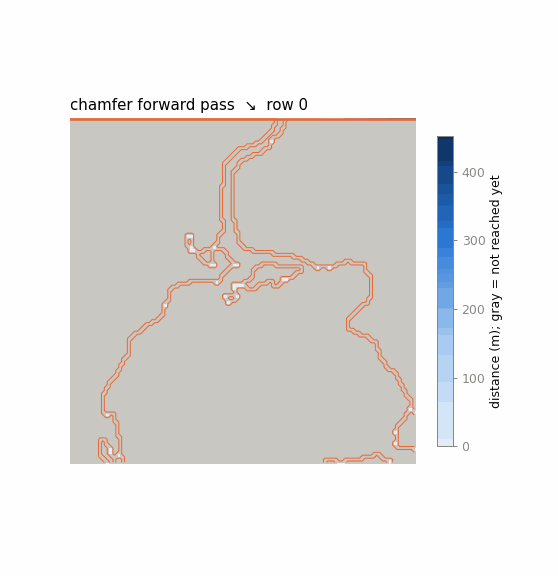

In [13]:
def animate_chamfer(seeds, path, a=1.0, b=math.sqrt(2), rows_per_frame=2):
    H, W = seeds.shape; INF = np.inf
    d = np.where(seeds, 0.0, INF); frames = []
    def snap(phase, i): frames.append((phase, i, d.copy()))
    for i in range(H):
        for j in range(W):
            v = d[i, j]
            if i > 0:
                if j > 0: v = min(v, d[i-1, j-1] + b)
                v = min(v, d[i-1, j] + a)
                if j < W - 1: v = min(v, d[i-1, j+1] + b)
            if j > 0: v = min(v, d[i, j-1] + a)
            d[i, j] = v
        if i % rows_per_frame == 0: snap("forward pass  ↘", i)
    for i in range(H - 1, -1, -1):
        for j in range(W - 1, -1, -1):
            v = d[i, j]
            if i < H - 1:
                if j < W - 1: v = min(v, d[i+1, j+1] + b)
                v = min(v, d[i+1, j] + a)
                if j > 0: v = min(v, d[i+1, j-1] + b)
            if j < W - 1: v = min(v, d[i, j+1] + a)
            d[i, j] = v
        if i % rows_per_frame == 0: snap("backward pass ↖", i)
    frames += [frames[-1]] * 15
    vmax = np.nanmax(np.where(np.isinf(d), np.nan, d)) * RES
    fig, ax = plt.subplots(figsize=(6.2, 6.4))
    cmap = DIST_CMAP.copy(); cmap.set_bad(UNREACHED)
    im = ax.imshow(np.zeros_like(d), cmap=cmap, vmin=0, vmax=vmax)
    ax.contour(seeds, levels=[0.5], colors=ORANGE, linewidths=0.8)
    scan = ax.axhline(0, color=ORANGE, lw=2); ax.set_axis_off()
    ttl = ax.set_title("", loc="left")
    fig.colorbar(im, ax=ax, shrink=0.7, label="distance (m); gray = not reached yet")
    def update(k):
        phase, i, v = frames[k]
        im.set_data(np.ma.masked_invalid(np.where(np.isinf(v), np.nan, v * RES)))
        scan.set_ydata([i]); ttl.set_text(f"chamfer {phase}  row {i}")
        return im, scan, ttl
    FuncAnimation(fig, update, frames=len(frames)).save(path, writer=PillowWriter(fps=20))
    plt.close(fig); return path

ANIM_CROP = (slice(1000, 1120), slice(2860, 2980))                 # 120 x 120 px = 960 m, marsh creeks
display(Image(filename=animate_chamfer(seeds[ANIM_CROP], OUT_DIR / "anim_chamfer_two_pass.gif")))

## 7. Method 3: exact separable Euclidean distance transform (Felzenszwalb–Huttenlocher)

The exact 2-D answer is still built from your 1-D sweeps:

**Phase 1 (your idea, per column):** forward/backward march down each column. This gives `g[i,j]`, the vertical distance to the
nearest seed in that column.

**Phase 2 (per row):** the exact squared distance is

$$D^2(i,j) = \min_{j'} \big[(j-j')^2 + g(i,j')^2\big],$$

the **lower envelope of parabolas**, one parabola rooted at each column $j'$ with height $g^2$. One left-to-right sweep
builds the envelope (dropping parabolas that are fully hidden) and a second sweep reads it off. Both phases are
$O(n)$, so the whole transform is $O(N)$, and every row and column is independent, so it parallelises across cores.

In [14]:
@nb.njit(cache=True)
def _envelope_1d(f, out, v, z):
    # Lower envelope of parabolas y = (q - p)^2 + f[p]  (Felzenszwalb & Huttenlocher, 2012).
    n = f.shape[0]
    k = 0; v[0] = 0; z[0] = -1e30; z[1] = 1e30
    for q in range(1, n):
        s = ((f[q] + q * q) - (f[v[k]] + v[k] * v[k])) / (2.0 * (q - v[k]))
        while s <= z[k]:
            k -= 1
            s = ((f[q] + q * q) - (f[v[k]] + v[k] * v[k])) / (2.0 * (q - v[k]))
        k += 1; v[k] = q; z[k] = s; z[k + 1] = 1e30
    k = 0
    for q in range(n):
        while z[k + 1] < q:
            k += 1
        out[q] = (q - v[k]) ** 2 + f[v[k]]

@nb.njit(parallel=True, cache=True)
def edt_fh(seeds):
    H, W = seeds.shape
    g = np.empty((H, W))
    for j in nb.prange(W):                          # phase 1: your 1-D march, down each column
        prev = 1e10
        for i in range(H):
            prev = 0.0 if seeds[i, j] else prev + 1.0
            g[i, j] = prev
        for i in range(H - 2, -1, -1):
            if g[i + 1, j] + 1.0 < g[i, j]:
                g[i, j] = g[i + 1, j] + 1.0
    out = np.empty((H, W))
    for i in nb.prange(H):                          # phase 2: parabola envelope along each row
        f = g[i] ** 2
        v = np.empty(W, np.int64); z = np.empty(W + 1); o = np.empty(W)
        _envelope_1d(f, o, v, z)
        out[i] = np.sqrt(o)
    return out

edt_fh(seeds[:8, :8])                                                # JIT warm-up
t_fh, d_fh = best_time(lambda: edt_fh(seeds_pad))
D_EDT = d_fh[unpad] * RES; del d_fh
record("Exact EDT, Felzenszwalb–Huttenlocher (numba)", "raster", "numba, parallel", seeds_pad.size, t_fh, D_EDT)
print(f"FH EDT on {seeds_pad.size/1e6:.0f} Mpx: {t_fh:.2f}s")

FH EDT on 132 Mpx: 0.27s


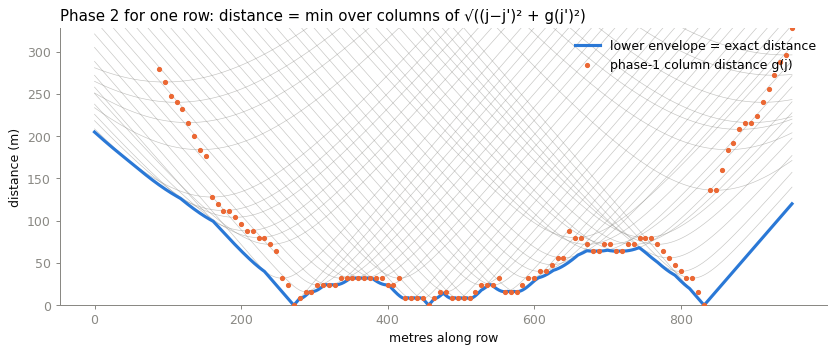

In [15]:
# Visualising phase 2 on one row of the crop: each column contributes a parabola; the answer is their lower envelope.
row_seeds = seeds[ANIM_CROP][60]
g_col = np.array([march_1d(list(seeds[ANIM_CROP][:, j]))[60] for j in range(seeds[ANIM_CROP].shape[1])])
x = np.linspace(0, len(g_col) - 1, 1200)
fig, ax = plt.subplots(figsize=(11, 4))
finite = np.isfinite(g_col)
for jp in np.where(finite)[0][::2]:
    ax.plot(x * RES, np.sqrt((x - jp) ** 2 + g_col[jp] ** 2) * RES, color=MUTED, lw=0.5, alpha=0.5)
env = np.sqrt(np.min((x[:, None] - np.where(finite)[0][None, :]) ** 2 + g_col[finite][None, :] ** 2, axis=1))
ax.plot(x * RES, env * RES, color=BLUE, lw=2.5, label="lower envelope = exact distance")
ax.scatter(np.where(finite)[0] * RES, g_col[finite] * RES, s=10, color=ORANGE, zorder=3, label="phase-1 column distance g(j)")
ax.set_ylim(0, np.nanmax(env * RES) * 1.6); ax.set_xlabel("metres along row"); ax.set_ylabel("distance (m)")
ax.set_title("Phase 2 for one row: distance = min over columns of √((j−j')² + g(j')²)", loc="left")
ax.legend(frameon=False, loc="upper right"); plt.show()

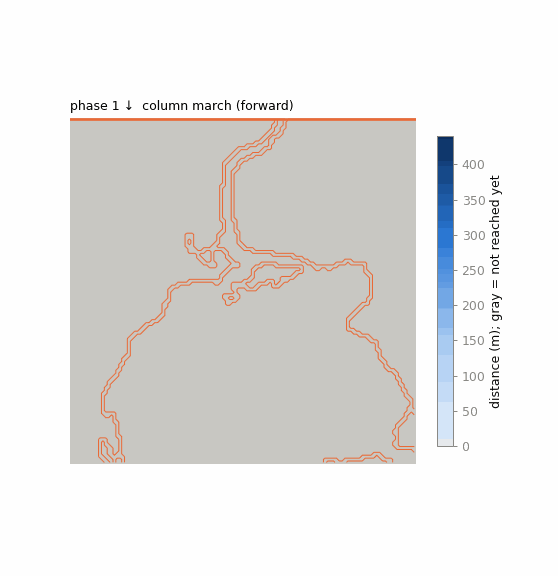

In [16]:
def animate_fh(seeds, path, step=3):
    H, W = seeds.shape; INF = np.inf
    g = np.full((H, W), INF); frames = []
    for i in range(H):                                            # phase 1 forward (all columns at once)
        g[i] = np.where(seeds[i], 0, (g[i - 1] + 1) if i else INF)
        if i % step == 0: frames.append(("phase 1 ↓  column march (forward)", "row", i, g.copy()))
    for i in range(H - 2, -1, -1):                                # phase 1 backward
        g[i] = np.minimum(g[i], g[i + 1] + 1)
        if i % step == 0: frames.append(("phase 1 ↑  column march (backward)", "row", i, g.copy()))
    D = g.copy(); jj = np.arange(W)
    for i in range(H):                                            # phase 2 row by row
        D[i] = np.sqrt(np.min((jj[:, None] - jj[None, :]) ** 2 + g[i][None, :] ** 2, axis=1))
        if i % step == 0: frames.append(("phase 2 →  parabola envelope per row", "row", i, D.copy()))
    frames += [frames[-1]] * 15
    vmax = np.nanmax(np.where(np.isinf(D), np.nan, D)) * RES
    fig, ax = plt.subplots(figsize=(6.2, 6.4))
    cmap = DIST_CMAP.copy(); cmap.set_bad(UNREACHED)
    im = ax.imshow(np.zeros((H, W)), cmap=cmap, vmin=0, vmax=vmax)
    ax.contour(seeds, levels=[0.5], colors=ORANGE, linewidths=0.8)
    scan = ax.axhline(0, color=ORANGE, lw=2); ax.set_axis_off(); ttl = ax.set_title("", loc="left", fontsize=10)
    fig.colorbar(im, ax=ax, shrink=0.7, label="distance (m); gray = not reached yet")
    def update(k):
        label, _, i, v = frames[k]
        im.set_data(np.ma.masked_invalid(np.where(np.isinf(v), np.nan, v * RES)))
        scan.set_ydata([i]); ttl.set_text(label)
        return im, scan, ttl
    FuncAnimation(fig, update, frames=len(frames)).save(path, writer=PillowWriter(fps=20))
    plt.close(fig); return path

display(Image(filename=animate_fh(seeds[ANIM_CROP], OUT_DIR / "anim_exact_edt_two_phase.gif")))

## 8. Method 4: `scipy.ndimage.distance_transform_edt`: the tried-and-true call

This is the standard library answer: an exact EDT in C (Maurer, Qi & Raghavan 2003, the same family as Method 3).
It is single-threaded, but compiled and well tested. It also shows the **tile-edge problem**: without padding, pixels near the
edge ignore shoreline just outside the tile.

padded: 3.32s | identical to numba FH: True


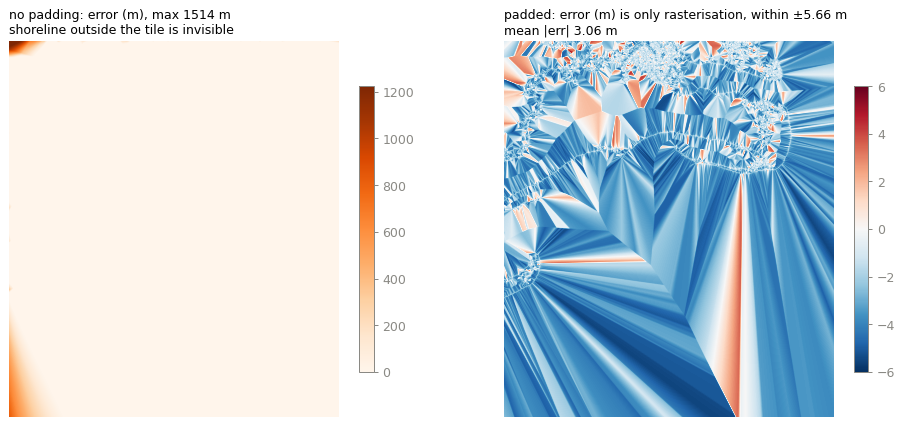

In [16]:
t_sp, d_sp = best_time(lambda: ndimage.distance_transform_edt(~seeds_pad))
D_SCIPY = d_sp[unpad] * RES; del d_sp
record("scipy distance_transform_edt (padded)", "raster", "SciPy (C, 1 thread)", seeds_pad.size, t_sp, D_SCIPY)
print(f"padded: {t_sp:.2f}s | identical to numba FH: {np.allclose(D_SCIPY, D_EDT)}")

t_np, d_nopad = best_time(lambda: ndimage.distance_transform_edt(~seeds) * RES)
record("scipy EDT, tile only (no padding)", "raster", "SciPy (C, 1 thread)", seeds.size, t_np, d_nopad, "edge errors")

fig, axs = plt.subplots(1, 2, figsize=(13, 5.5))
e = d_nopad - D_REF
im = axs[0].imshow(e, cmap="Oranges", vmin=0, vmax=np.percentile(e[e > 10], 99) if (e > 10).any() else 1)
axs[0].set_title(f"no padding: error (m), max {e.max():.0f} m\nshoreline outside the tile is invisible", loc="left", fontsize=10)
fig.colorbar(im, ax=axs[0], shrink=0.75); axs[0].set_axis_off()
e = D_SCIPY - D_REF
im = axs[1].imshow(e, cmap=ERR_CMAP, vmin=-6, vmax=6)
axs[1].set_title(f"padded: error (m) is only rasterisation, within ±{RES*np.sqrt(2)/2:.2f} m\nmean |err| {np.abs(e).mean():.2f} m",
                 loc="left", fontsize=10)
fig.colorbar(im, ax=axs[1], shrink=0.75); axs[1].set_axis_off()
plt.show()

## 9. Method 6: vector dead reckoning with a boundary halo and local refinement

This combines the speed of two-pass sweeps with vector-exact answers, without padding the array. Three ideas:

1. **Propagate pointers, not numbers.** Instead of carrying a distance (chamfer) or a pixel offset (Danielsson / 8SSEDT),
   each pixel carries a pointer to an actual **shoreline vertex** (sub-pixel position). When a neighbour offers a different
   vertex, we compute the true Euclidean distance to it and keep the closer one. This is "dead reckoning" (Grevera 2004)
   with vector features, so there is no rasterisation error.
2. **Halo seeding instead of padding.** If shoreline point *q* is nearest to pixel *p*, it is also nearest to every point on the
   segment *p→q*, including where that segment crosses the tile edge. So we ask the KD-tree for the true nearest vertex of the
   **border pixels only** (about 16 k queries) and let the sweeps carry those pointers inward. Shoreline outside the tile is
   handled with **no padding**: 15.8 M px instead of 132 M.
3. **Local refinement.** Each seed pixel starts with one vertex. A quick search of the vertices binned in the 3×3 cells around a
   pixel's current vertex finds the true nearest point along that stretch of shoreline. Alternating one propagation pass with
   one refinement step makes the remaining errors disappear quickly.

The sweep uses a 5×5 neighbourhood (the 8 already-visited neighbours of the 3×3 plus 4 "knight's move" cells), which removes
most of the classic failures where Voronoi regions are very thin.

In [17]:
@nb.njit(cache=True)
def dr_sweeps(fid, px_x, px_y, ptx, pty, npass, offs):
    # Forward/backward sweeps propagating pointers (fid) to real shoreline vertices.
    H, W = fid.shape
    d = np.full((H, W), np.inf)
    for i in range(H):
        for j in range(W):
            k = fid[i, j]
            if k >= 0:
                d[i, j] = math.hypot(px_x[j] - ptx[k], px_y[i] - pty[k])
    for _ in range(npass):
        for sgn in (1, -1):                                       # +1 forward (↘), -1 backward (↖)
            for ii in range(H):
                i = ii if sgn == 1 else H - 1 - ii
                for jj in range(W):
                    j = jj if sgn == 1 else W - 1 - jj
                    best = d[i, j]; bk = fid[i, j]
                    for m in range(offs.shape[0]):
                        a = i + sgn * offs[m, 0]; c = j + sgn * offs[m, 1]
                        if a < 0 or a >= H or c < 0 or c >= W:
                            continue
                        k = fid[a, c]
                        if k < 0 or k == bk:
                            continue
                        dd = math.hypot(px_x[j] - ptx[k], px_y[i] - pty[k])
                        if dd < best:
                            best = dd; bk = k
                    d[i, j] = best; fid[i, j] = bk
    return d

@nb.njit(parallel=True, cache=True)
def dr_refine(fid, d, px_x, px_y, ptx, pty, cell_ids, starts, ends, gx0, gy0, cs, gW):
    # For each pixel, search the vertices in the 3x3 bins around its current vertex; keep the closest.
    H, W = fid.shape
    for i in nb.prange(H):
        for j in range(W):
            k = fid[i, j]
            if k < 0:
                continue
            cx = int((ptx[k] - gx0) // cs); cy = int((gy0 - pty[k]) // cs)
            best = d[i, j]; bk = k
            for dy in range(-1, 2):
                for dx in range(-1, 2):
                    cid = (cy + dy) * gW + (cx + dx)
                    p = np.searchsorted(cell_ids, cid)
                    if p < cell_ids.shape[0] and cell_ids[p] == cid:
                        for q in range(starts[p], ends[p]):
                            dd = math.hypot(px_x[j] - ptx[q], px_y[i] - pty[q])
                            if dd < best:
                                best = dd; bk = q
            d[i, j] = best; fid[i, j] = bk
    return d

# forward-visited offsets (backward = negated): 3x3 causal neighbours + knight moves
OFFS_5x5 = np.array([(i, j) for i in range(-2, 1) for j in range(-2, 3)
                     if (i < 0 or j < 0) and abs(i) + abs(j) <= 3 and (i, j) != (0, 0)], np.int64)

def build_vertex_bins(pts, cs):
    gx0, gy0 = BUF_BOX[0], BUF_BOX[3]
    gW = int(math.ceil((BUF_BOX[2] - BUF_BOX[0]) / cs)) + 2
    cid = ((gy0 - pts[:, 1]) // cs).astype(np.int64) * gW + ((pts[:, 0] - gx0) // cs).astype(np.int64)
    order = np.argsort(cid, kind="stable")
    cell_ids, starts = np.unique(cid[order], return_index=True)
    ends = np.append(starts[1:], len(order))
    return order, cell_ids, starts, ends, gx0, gy0, gW

def vector_dead_reckoning(rounds=2, offs=OFFS_5x5, return_fid=False):
    order, cell_ids, starts, ends, gx0, gy0, gW = build_vertex_bins(PTS, RES)
    ptx = np.ascontiguousarray(PTS[order, 0]); pty = np.ascontiguousarray(PTS[order, 1])
    sorted_tree = cKDTree(np.column_stack([ptx, pty]))           # in practice: reuse TREE with an index remap
    fid = np.full((H, W), -1, np.int64)
    si, sj = np.nonzero(seeds)                                     # (1) seed pixels -> nearest vertex
    fid[si, sj] = sorted_tree.query(np.column_stack([PX_X[sj], PX_Y[si]]), workers=-1)[1]
    halo = np.zeros((H, W), bool); halo[[0, -1], :] = True; halo[:, [0, -1]] = True; halo &= ~seeds
    bi, bj = np.nonzero(halo)                                      # (2) halo: border pixels -> global nearest vertex
    fid[bi, bj] = sorted_tree.query(np.column_stack([PX_X[bj], PX_Y[bi]]), workers=-1)[1]
    d = dr_sweeps(fid, PX_X, PX_Y, ptx, pty, 2, offs)             # two forward+backward passes
    for r in range(rounds):                                        # (3) refine <-> propagate
        d = dr_refine(fid, d, PX_X, PX_Y, ptx, pty, cell_ids, starts, ends, gx0, gy0, RES, gW)
        if r < rounds - 1:
            d = dr_sweeps(fid, PX_X, PX_Y, ptx, pty, 1, offs)
    return (d, fid) if return_fid else d

# JIT warm-up on a tiny problem
dr_sweeps(np.full((4, 4), -1, np.int64), PX_X[:4], PX_Y[:4], PTS[:, 0].copy(), PTS[:, 1].copy(), 1, OFFS_5x5)
dr_refine(np.full((4, 4), -1, np.int64), np.zeros((4, 4)), PX_X[:4], PX_Y[:4], PTS[:, 0].copy(), PTS[:, 1].copy(),
          np.zeros(1, np.int64), np.zeros(1, np.int64), np.zeros(1, np.int64), 0.0, 0.0, 1.0, 1)

for rounds in (1, 2, 3):
    t, d = best_time(lambda: vector_dead_reckoning(rounds), repeat=1)
    r = record(f"Vector dead reckoning ({rounds} refine round{'s' if rounds > 1 else ''})", "hybrid", "numba", H * W, t, d,
               "no padding needed")
    print(f"rounds={rounds}: {t:5.2f}s  mean |err| {r['mean_abs_err_m']*1000:6.2f} mm  max {r['max_abs_err_m']:5.2f} m  "
          f"within 1 m: {r['pct_within_1m']:.4f}%")
    if rounds == 2:
        D_DR = d

rounds=1:  2.49s  mean |err|  12.70 mm  max  7.92 m  within 1 m: 99.5265%
rounds=2:  3.83s  mean |err|   2.12 mm  max  3.97 m  within 1 m: 99.9373%
rounds=3:  5.14s  mean |err|   0.32 mm  max  3.97 m  within 1 m: 99.9987%


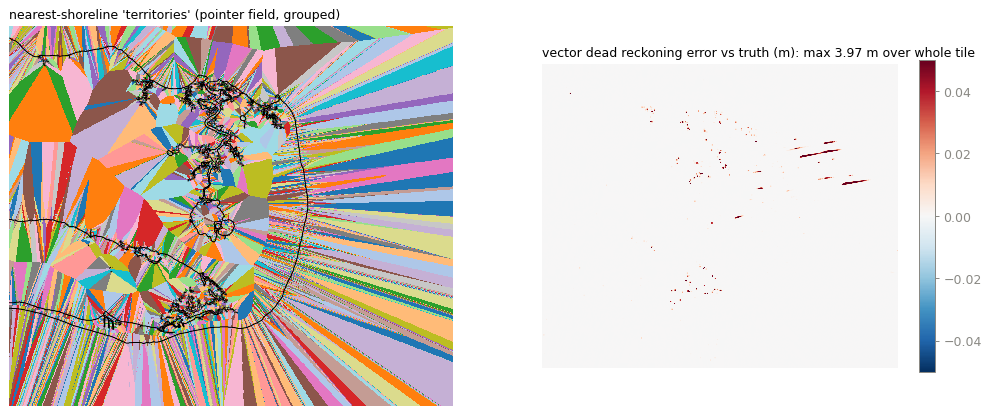

In [18]:
# What the pointers look like: each pixel coloured by WHICH shoreline vertex it points at = a Voronoi map of the shoreline.
_, fid = vector_dead_reckoning(2, return_fid=True)
win = (slice(500, 1700), slice(2300, 3700))
rng_perm = np.random.default_rng(1).permutation(fid.max() + 1)
fig, axs = plt.subplots(1, 2, figsize=(14, 6))
axs[0].imshow(rng_perm[fid[win] // 40] % 256, cmap="tab20", interpolation="nearest")
axs[0].contour(seeds[win], levels=[0.5], colors="k", linewidths=0.4)
axs[0].set_title("nearest-shoreline 'territories' (pointer field, grouped)", loc="left", fontsize=10); axs[0].set_axis_off()
e = (D_DR - D_REF)[win]
im = axs[1].imshow(e, cmap=ERR_CMAP, vmin=-0.05, vmax=0.05)
axs[1].set_title(f"vector dead reckoning error vs truth (m): max {np.abs(D_DR - D_REF).max():.2f} m over whole tile", loc="left", fontsize=10)
axs[1].set_axis_off(); fig.colorbar(im, ax=axs[1], shrink=0.75)
plt.show()

## 10. Results
All raster methods are scored after padding to the search buffer (they must process the padded grid to be correct). The
vector and hybrid methods work on the tile grid directly. Errors are measured against the vector truth on all 15.8 M pixels.

In [19]:
df = pd.DataFrame(results)
df["speed-up vs KD-tree"] = df.loc[df.method.str.startswith("KD-tree"), "seconds"].iloc[0] / df.seconds
cols = ["method", "family", "implementation", "pixels_processed", "seconds", "Mpx_per_s", "speed-up vs KD-tree",
        "mean_abs_err_m", "max_abs_err_m", "pct_within_1m", "note"]
df = df[cols].sort_values("seconds").reset_index(drop=True)
df.to_csv(OUT_DIR / "benchmark_results.csv", index=False)
(df.style.format({"pixels_processed": "{:,.0f}", "seconds": "{:,.2f}", "Mpx_per_s": "{:,.2f}", "speed-up vs KD-tree": "{:,.2f}×",
                  "mean_abs_err_m": "{:,.3f}", "max_abs_err_m": "{:,.2f}", "pct_within_1m": "{:.3f}"}, na_rep="—")
   .hide(axis="index"))

method,family,implementation,pixels_processed,seconds,Mpx_per_s,speed-up vs KD-tree,mean_abs_err_m,max_abs_err_m,pct_within_1m,note
"1-D march, rows only",raster,"numba, parallel rows","131,837,104",0.04,"3,018.95",707.32×,"7,454.509","32,172.02",0.806,horizontal distance only
"1-D march, min(rows, cols)",raster,numba,"131,837,104",0.09,"1,509.48",353.66×,"2,850.915","20,051.50",1.815,axis directions only
"Exact EDT, Felzenszwalb–Huttenlocher (numba)",raster,"numba, parallel","131,837,104",0.27,482.28,112.99×,3.064,5.72,9.826,
Chamfer chessboard (numba),raster,numba,"131,837,104",0.39,340.72,79.83×,729.357,"5,164.49",1.646,
Chamfer Borgefors optimal (numba),raster,numba,"131,837,104",0.39,340.40,79.75×,141.680,985.53,2.920,
Chamfer 1-√2 (numba),raster,numba,"131,837,104",0.39,339.84,79.62×,257.561,"1,586.45",3.743,
"scipy EDT, tile only (no padding)",raster,"SciPy (C, 1 thread)","15,812,104",0.43,36.74,71.77×,11.497,"1,514.24",9.785,edge errors
Vector dead reckoning (1 refine round),hybrid,numba,"15,812,104",2.49,6.35,12.40×,0.013,7.92,99.527,no padding needed
scipy distance_transform_edt (padded),raster,"SciPy (C, 1 thread)","131,837,104",3.32,39.68,9.30×,3.064,5.72,9.826,
Vector dead reckoning (2 refine rounds),hybrid,numba,"15,812,104",3.83,4.13,8.06×,0.002,3.97,99.937,no padding needed


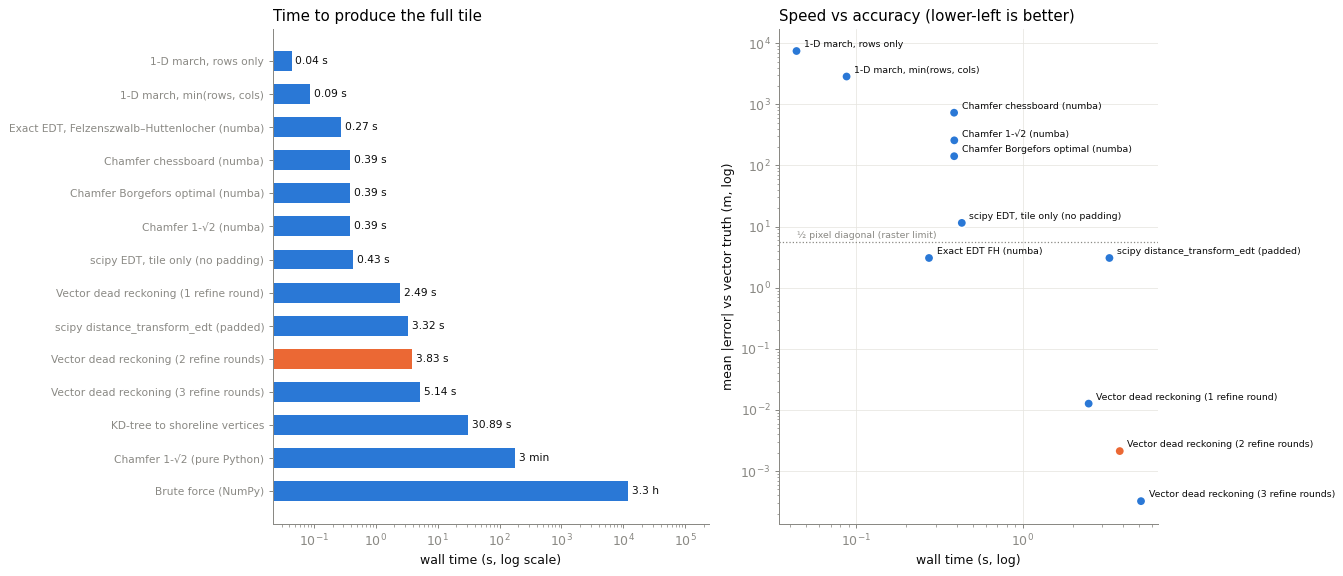

In [20]:
RECOMMENDED = "Vector dead reckoning (2 refine rounds)"   # highlighted in orange
plot_df = df.sort_values("seconds", ascending=True)
fig, axs = plt.subplots(1, 2, figsize=(15, 6.5), width_ratios=[1.15, 1])

ax = axs[0]
colors = [ORANGE if m == RECOMMENDED else BLUE for m in plot_df.method]
ax.barh(plot_df.method, plot_df.seconds, color=colors, height=0.6)
for y, (sec, impl) in enumerate(zip(plot_df.seconds, plot_df.implementation)):
    lbl = f"{sec:,.2f} s" if sec < 60 else (f"{sec/60:,.0f} min" if sec < 3600 else f"{sec/3600:,.1f} h")
    ax.text(sec * 1.15, y, lbl, va="center", fontsize=8.5, color=INK)
ax.set_xscale("log"); ax.invert_yaxis(); ax.set_xlabel("wall time (s, log scale)")
ax.set_title("Time to produce the full tile", loc="left")
ax.set_xlim(plot_df.seconds.min() / 2, plot_df.seconds.max() * 20)
ax.tick_params(axis="y", labelsize=8.5)

ax = axs[1]
sc = df.dropna(subset=["mean_abs_err_m"])
sc = sc[sc.mean_abs_err_m > 0]
ax.scatter(sc.seconds, sc.mean_abs_err_m, s=60, color=[ORANGE if m == RECOMMENDED else BLUE for m in sc.method],
           edgecolor="white", linewidth=1.5, zorder=3)
for _, r in sc.iterrows():
    ax.annotate(r.method.replace(", Felzenszwalb–Huttenlocher", " FH"), (r.seconds, r.mean_abs_err_m), fontsize=7.5,
                xytext=(6, 3), textcoords="offset points", color=INK)
ax.set_xscale("log"); ax.set_yscale("log"); ax.grid(True, which="major", color="#e6e5e0", lw=0.6)
ax.axhline(RES * np.sqrt(2) / 2, color=MUTED, ls=":", lw=1)
ax.text(sc.seconds.min(), RES * np.sqrt(2) / 2 * 1.15, "½ pixel diagonal (raster limit)", fontsize=7.5, color=MUTED)
ax.set_xlabel("wall time (s, log)"); ax.set_ylabel("mean |error| vs vector truth (m, log)")
ax.set_title("Speed vs accuracy (lower-left is better)", loc="left")
plt.tight_layout(); plt.savefig(OUT_DIR / "benchmark.png", dpi=130, bbox_inches="tight"); plt.show()

## 11. Final product: distance-to-shoreline GeoTIFF on the BlueTopo grid

We write the **vector dead-reckoning** result: about millimetre accuracy against the CUSP vector shoreline, no padding, a few seconds.
The output keeps the BlueTopo grid exactly (same CRS, transform, width and height, 8 m pixels), stored as float32 metres.
If you need a dependency-light alternative, padded `scipy.ndimage.distance_transform_edt` is within ±5.7 m.

> Distances are Euclidean in the UTM projection plane. UTM scale distortion at this longitude is about 1.0003 (about 7 m at
> 22 km). Divide by the local point scale factor if you need ellipsoidal (geodesic) metres.

In [21]:
D_FINAL = D_DR.astype(np.float32)
NODATA = -9999.0
if MASK_TO_BLUETOPO:
    D_FINAL = np.where(elev.mask, NODATA, D_FINAL).astype(np.float32)

OUT_TIF = OUT_DIR / f"distance_to_shoreline_{TILE_ID}_8m.tif"
profile = dict(driver="GTiff", height=H, width=W, count=1, dtype="float32", crs=OUT_CRS, transform=TRANSFORM,
               nodata=NODATA, compress="deflate", predictor=3, tiled=True, blockxsize=512, blockysize=512)
with rasterio.open(OUT_TIF, "w", **profile) as dst:
    dst.write(D_FINAL, 1)
    dst.set_band_description(1, "Distance to nearest CUSP shoreline (m)")
    dst.update_tags(SOURCE_BATHY=TIF.name, SOURCE_SHORELINE="NOAA NGS CUSP", METHOD="vector dead reckoning + halo + refinement",
                    UNITS="metre", SEARCH_BUFFER_M=SEARCH_BUFFER_M)

with rasterio.open(OUT_TIF) as chk, rasterio.open(TIF) as src:
    assert chk.shape == src.shape and chk.transform == src.transform and chk.crs == src.crs
    print(f"{OUT_TIF}  {chk.width}x{chk.height} @ {chk.res[0]} m  |  {OUT_TIF.stat().st_size/1e6:.1f} MB  |  "
          f"range {np.nanmin(D_FINAL[D_FINAL != NODATA]):.1f} – {D_FINAL.max():,.0f} m")

outputs/distance_to_shoreline_BF2GS2KS_8m.tif  3724x4246 @ 8.0 m  |  21.1 MB  |  range 0.0 – 22,985 m


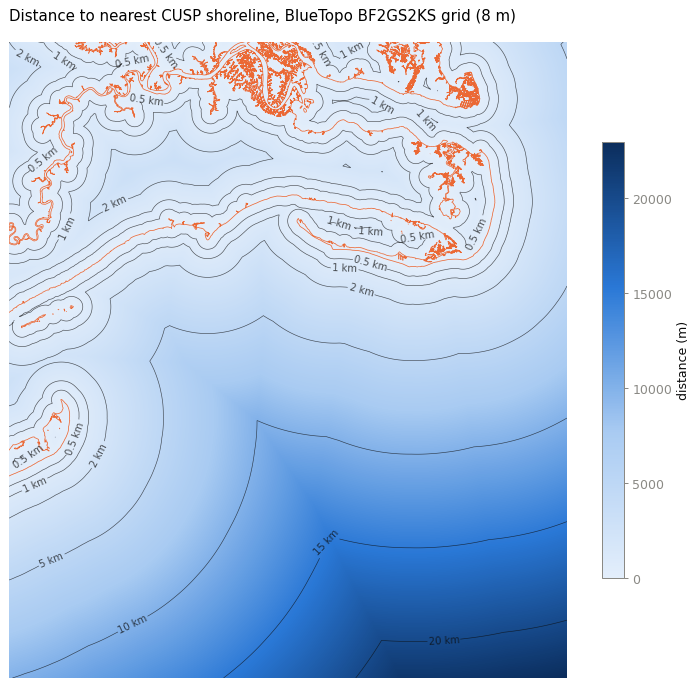

In [22]:
fig, ax = plt.subplots(figsize=(10, 10.5))
shown = np.ma.masked_equal(D_FINAL, NODATA)
im = ax.imshow(shown, extent=ext, cmap=DIST_CMAP, vmin=0)
levels = [500, 1000, 2000, 5000, 10000, 15000, 20000]
cs = ax.contour(PX_X, PX_Y, D_FINAL, levels=levels, colors=INK, linewidths=0.5, alpha=0.7)
ax.clabel(cs, fmt=lambda v: f"{v/1000:g} km", fontsize=8)
shore.clip(shapely.box(*BOUNDS)).plot(ax=ax, color=ORANGE, lw=0.6)
ax.set_xlim(BOUNDS.left, BOUNDS.right); ax.set_ylim(BOUNDS.bottom, BOUNDS.top)
ax.set_title(f"Distance to nearest CUSP shoreline, BlueTopo {TILE_ID} grid (8 m)", loc="left")
fig.colorbar(im, ax=ax, shrink=0.6, label="distance (m)"); ax.set_axis_off()
plt.savefig(OUT_DIR / f"distance_to_shoreline_{TILE_ID}.png", dpi=110, bbox_inches="tight"); plt.show()

## 12. Animation: the distance field as an expanding wavefront

Another way to see the result: a front starting at every shoreline at once and moving outward at constant speed (the
"brushfire" / grassfire view of a distance transform). Where two fronts meet is the medial axis, the ridge where a pixel is
equally far from two shorelines. This is the "turn back when you hit another shoreline" point from your original idea.

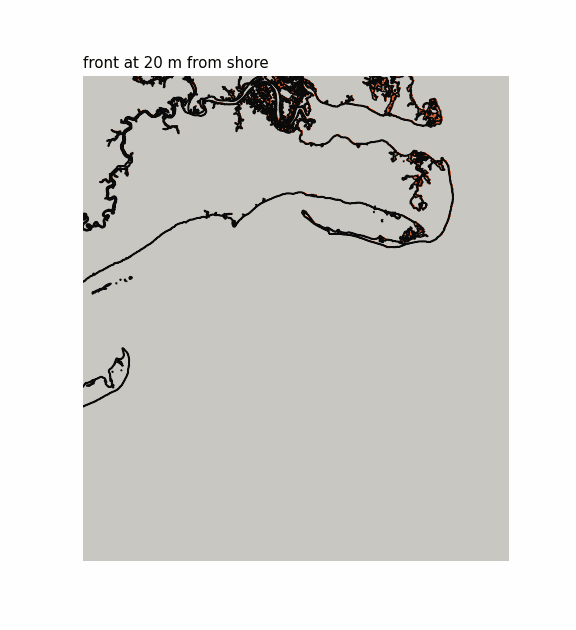

In [23]:
def animate_wavefront(D, seeds, path, n_frames=70, ds=5):
    Dd = D[::ds, ::ds]; Sd = seeds[::ds, ::ds] | ndimage.maximum_filter(seeds, ds)[::ds, ::ds]
    radii = np.concatenate([np.geomspace(20, Dd.max(), n_frames)])
    fig, ax = plt.subplots(figsize=(6.4, 7))
    base = ax.imshow(np.zeros_like(Dd), cmap=mcolors.ListedColormap([UNREACHED]), vmin=0, vmax=1)
    cmap = DIST_CMAP.copy(); cmap.set_bad((0, 0, 0, 0))
    im = ax.imshow(np.ma.masked_all(Dd.shape), cmap=cmap, vmin=0, vmax=Dd.max())
    ax.imshow(np.ma.masked_where(~Sd, Sd), cmap=mcolors.ListedColormap([ORANGE]), interpolation="nearest")
    ax.set_axis_off(); ttl = ax.set_title("", loc="left")
    front = [None]
    def update(k):
        r = radii[min(k, n_frames - 1)]
        im.set_data(np.ma.masked_where(Dd > r, Dd))
        if front[0] is not None:
            front[0].remove()
        front[0] = ax.contour(Dd, levels=[r], colors=INK, linewidths=1.2)
        ttl.set_text(f"front at {r:,.0f} m from shore")
        return [im]
    FuncAnimation(fig, update, frames=n_frames + 12).save(path, writer=PillowWriter(fps=14))
    plt.close(fig); return path

display(Image(filename=animate_wavefront(D_FINAL.astype(float), seeds, OUT_DIR / "anim_wavefront.gif")))

## 13. Takeaways

* **Your marching idea is the right building block.** In 1-D, a forward sweep that counts up and resets at shore, followed by a
  backward sweep taking the minimum, is exact and $O(n)$. In 2-D it becomes
  * the **chamfer** transform: fastest of all, but only approximate (about 0.5–8% error growing with distance), or
  * **phase 1 of the exact EDT**: march the columns, then combine rows with a parabola envelope. This is exact and $O(N)$.
* **The library default** (`scipy.ndimage.distance_transform_edt`) is exact *on the raster*, but you must (a) pad the array
  out to the farthest relevant shoreline and (b) accept up to ±½ pixel diagonal (±5.7 m at 8 m) from rasterising the line.
* **The fastest exact raster method is the parallel numba Felzenszwalb–Huttenlocher EDT.** It gives identical output to SciPy
  but uses every core, about 13× faster on this machine even on the 8× padded array. If ±½ pixel is good enough
  (it usually is for an 8 m product), use this.
* **The brute-force vector reference** (KD-tree) is exact and easy, but processes each far-offshore pixel the hard way.
* **Vector dead reckoning with a halo and refinement** gives near-exact vector distances (millimetre mean error), needs no padding
  thanks to the halo-seeding argument, and runs about 8× faster than the KD-tree. It is the recommended method when the
  numbers must be true metres to the CUSP shoreline rather than to its rasterised pixels. It produces the GeoTIFF above.

**Ideas for further work**
* *Over-water (geodesic) distance*, the distance a boat would travel without crossing land. Use the land mask as an obstacle and
  solve the eikonal equation with Fast Marching (`scikit-fmm`) or Dijkstra/brushfire. Your "go backwards when you hit
  another shoreline" intuition maps naturally onto this.
* *Signed distance:* negative on land, positive offshore, using CUSP's land/water side or a land polygon.
* *GPU:* the **Jump Flooding Algorithm** is an embarrassingly parallel cousin of dead reckoning (log₂ N passes).
* *Mosaics:* the halo trick makes the per-tile computation independent of neighbouring tiles, so BlueTopo tiles can be processed in parallel.

**References.** Rosenfeld & Pfaltz (1966), *Sequential operations in digital picture processing*, J. ACM ·
Borgefors (1986), *Distance transformations in digital images*, CVGIP · Danielsson (1980), *Euclidean distance mapping*, CGIP ·
Maurer, Qi & Raghavan (2003), *A linear time algorithm for computing exact Euclidean distance transforms*, IEEE PAMI ·
Grevera (2004), *The "dead reckoning" signed distance transform*, CVIU · Felzenszwalb & Huttenlocher (2012),
*Distance transforms of sampled functions*, Theory of Computing · Rong & Tan (2006), *Jump flooding in GPU*, I3D.